In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 

In [2]:
df = pd.read_csv(r"C:\Users\Pavitra\Downloads\AB_Testing_Project\data\ab_data.csv")
df.head()

,user_id,timestamp,group,landing_page,converted
0,851104,2017-01-21 22:11:48.556739,control,old_page,0
1,804228,2017-01-12 08:01:45.159739,control,old_page,0
2,661590,2017-01-11 16:55:06.154213,treatment,new_page,0
3,853541,2017-01-08 18:28:03.143765,treatment,new_page,0
4,864975,2017-01-21 01:52:26.210827,control,old_page,1


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 294478 entries, 0 to 294477
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   user_id       294478 non-null  int64 
 1   timestamp     294478 non-null  object
 2   group         294478 non-null  object
 3   landing_page  294478 non-null  object
 4   converted     294478 non-null  int64 
dtypes: int64(2), object(3)
memory usage: 11.2+ MB


In [4]:
df.describe()

,user_id,converted
count,294478.000000,294478.000000
mean,787974.124733,0.119659
std,91210.823776,0.324563
min,630000.000000,0.000000
25%,709032.250000,0.000000
50%,787933.500000,0.000000
75%,866911.750000,0.000000
max,945999.000000,1.000000


In [5]:
print("DATE MAX:",np.max(df['timestamp']))
print("DATE MIN:",np.min(df['timestamp']))

DATE MAX: 2017-01-24 13:41:54.460509
DATE MIN: 2017-01-02 13:42:05.378582


In [6]:
df.isnull().sum()

user_id         0
timestamp       0
group           0
landing_page    0
converted       0
dtype: int64

In [7]:
df['group'].value_counts()

group
treatment    147276
control      147202
Name: count, dtype: int64

In [8]:

df['landing_page'].value_counts()

landing_page
old_page    147239
new_page    147239
Name: count, dtype: int64

In [9]:
### I can see some group/landing_page imbalance from above 
### as , treatment ----> new_page and control -----> old_page 

In [10]:
# finding the users whose landing_page and group mismatched 

mismatched = df[~(((df['group']=='treatment') & (df['landing_page']=='new_page')) | ((df['group']=='control') & (df['landing_page']=='old_page')))]
print(f"Mismatched group/landing_page rows: {len(mismatched)}")

Mismatched group/landing_page rows: 3893


In [11]:
# finding users who were present in both the groups( control and treatment)

user_group_counts = df.groupby('user_id')['group'].nunique()
users_in_both = user_group_counts[user_group_counts > 1]
print(f"Users appearing in both groups: {len(users_in_both)}")

# can see that 1895 users had seen both the pages 

Users appearing in both groups: 1895


In [12]:
###  making the cleaned dataframe 

df_clean = df[((df['group']=='treatment') & (df['landing_page']=='new_page')) |
   ((df['group']=='control')   & (df['landing_page']=='old_page'))].copy()

contaminated_users = users_in_both.index
df_clean = df_clean[~df_clean['user_id'].isin(contaminated_users)]

In [13]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 288690 entries, 0 to 294477
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   user_id       288690 non-null  int64 
 1   timestamp     288690 non-null  object
 2   group         288690 non-null  object
 3   landing_page  288690 non-null  object
 4   converted     288690 non-null  int64 
dtypes: int64(2), object(3)
memory usage: 13.2+ MB


In [14]:
# dropping the duplicates 

df_clean = df_clean.drop_duplicates('user_id', keep='first')

In [15]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 288689 entries, 0 to 294477
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   user_id       288689 non-null  int64 
 1   timestamp     288689 non-null  object
 2   group         288689 non-null  object
 3   landing_page  288689 non-null  object
 4   converted     288689 non-null  int64 
dtypes: int64(2), object(3)
memory usage: 13.2+ MB


In [16]:
df_clean.to_csv("df_clean",index=False)

### Power analysis to determine the required sample size

In [17]:
### determining the baseline conversion rate 

In [18]:
df_clean = pd.read_csv(r"C:\Users\Pavitra\Downloads\AB_Testing_Project\notebooks\df_clean")
df_clean.head()

,user_id,timestamp,group,landing_page,converted
0,851104,2017-01-21 22:11:48.556739,control,old_page,0
1,804228,2017-01-12 08:01:45.159739,control,old_page,0
2,661590,2017-01-11 16:55:06.154213,treatment,new_page,0
3,853541,2017-01-08 18:28:03.143765,treatment,new_page,0
4,864975,2017-01-21 01:52:26.210827,control,old_page,1


In [19]:
baseline_rate = df_clean[df_clean['group']=='control']['converted'].mean()
baseline_rate

np.float64(0.12030492030492031)

In [20]:
# therefore , baseline conversion rate ~ 12%

In [21]:
### determing the MDE : What's the smallest effect worth detecting? and the alpha(significance value)

In [22]:
mde = 0.02
alpha = 0.05 # allowing 5% tolerance for a type I error

In [23]:
### determing the Power 

power = 0.8 # if the true effect is at least the specified MDE, the experiment has an 80% probability of detecting it as statistically significant

In [26]:
# calculating the required sample size 

from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize

effect_size = proportion_effectsize(baseline_rate + mde, baseline_rate)

analysis = NormalIndPower()
required_n = analysis.solve_power(effect_size=effect_size, alpha=alpha, power=power,    # effect_size=effect_size ,represents: 
                                                                                        # How large is the effect I want to detect? In our case: 12% → 14%
                                   ratio=1.0, alternative='two-sided')

# this basically asks : How large does my sample need to be so that I have an 80% chance of detecting a 12% → 14% difference at αlpha = 0.05?

print(f"Required sample size per group: {required_n:.0f}")

Required sample size per group: 4441


In [27]:
df_clean.groupby('group').count()

,user_id,timestamp,landing_page,converted
group,,,,
control,144300,144300,144300,144300
treatment,144389,144389,144389,144389


In [28]:
### therefore , we have enough samples per group to conduct this experiment at the required level 

### Checking for Novelty effect

In [29]:

df_clean['timestamp'] = pd.to_datetime(df_clean['timestamp'])
df_clean['date'] = df_clean['timestamp'].dt.date

daily = df_clean.groupby(['date','group'])['converted'].mean().unstack()
daily

group,control,treatment
date,,
2017-01-02,0.125618,0.119450
2017-01-03,0.113352,0.113799
2017-01-04,0.121936,0.116795
2017-01-05,0.123099,0.114855
2017-01-06,0.114916,0.123508
2017-01-07,0.121008,0.116527
2017-01-08,0.119151,0.120708
2017-01-09,0.119666,0.118381
2017-01-10,0.113262,0.126276


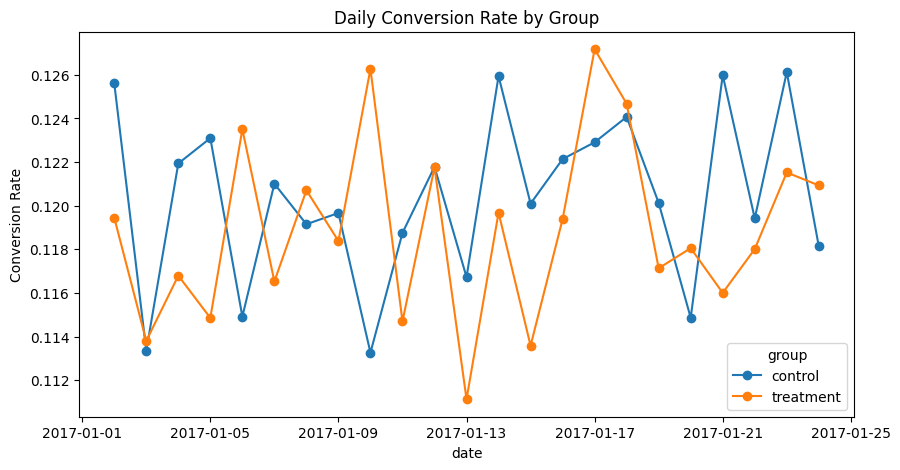

In [33]:
daily.plot(figsize=(10,5), marker='o')
plt.title('Daily Conversion Rate by Group')
plt.ylabel('Conversion Rate')
plt.savefig(r"C:\Users\Pavitra\Downloads\AB_Testing_Project\exports", dpi=150, bbox_inches='tight')
plt.show()

 **No clear novelty trend is visible.** 
* The treatment conversion rate **fluctuates above and below control** throughout the period.
* There are some short-term spikes, e.g. around **Jan 10 and Jan 17**, but they don't form a sustained pattern.
* Therefore, **visually there is no strong evidence of a novelty effect** (initial boost followed by decay).
* To confirm statistically, plot the **daily treatment − control conversion-rate difference** and test whether that difference has a significant downward trend.


In [35]:
daily['effect'] = (
    daily['treatment']
    - daily['control']
)

daily['day_num'] = range(len(daily))

In [36]:
import statsmodels.api as sm

X = sm.add_constant(daily['day_num'])
model = sm.OLS(daily['effect'], X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                 effect   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.048
Method:                 Least Squares   F-statistic:                 0.0001399
Date:                Tue, 25 Aug 2026   Prob (F-statistic):              0.991
Time:                        10:19:44   Log-Likelihood:                 87.782
No. Observations:                  23   AIC:                            -171.6
Df Residuals:                      21   BIC:                            -169.3
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0015      0.002     -0.667      0.5

In [38]:
### since P>|t| = 0.991 ----> There is no statistically significant evidence that the treatment-control difference changes linearly over time.
### No Novelty Effect
